In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))  # or however many levels up to reach the project root

import global_upreg_seq

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist


In [78]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
#consider imbalanced conditions as well
#later will move dist center to be up down and centered

def generate_and_save(output_dir, prefix, group_size, **kwargs):
    counts, labels, (log_fc_true, size_factors, log_base_means) = \
        global_upreg_seq.generate_simulated_data(group_size, **kwargs)
    
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    
    pd.DataFrame(counts.clone().detach().numpy().astype(int)).to_csv(out / f"{prefix}_counts.csv")
    pd.DataFrame({"condition": ["base" if l == 0 else "upreg" for l in labels]}).to_csv(out / f"{prefix}_metadata.csv")
    pd.DataFrame({
        "gene": [f"gene_{i}" for i in range(len(log_fc_true))],
        "true_log2fc": log_fc_true / np.log(2),
        "log_base_mean": log_base_means,
    }).to_csv(out / f"{prefix}_truth.csv", index=False)

for n in [5, 25,50]:
    for up in [0.3,0.55, 0.75]:
        for dist_center in [1.5]:
            for sample in range(5):
                generate_and_save("sims",
                 f"n{n}_de{int(up*100)}_decenter{int(dist_center)}_{sample}",
                 n,
                 gene_size=20000,
                 downreg_fraction=1.0-up,
                 median_log_upreg=dist_center,
                 log_base_mean_val=2.01)

                print(f"created: n{n}_de{int(up*100)}_decenter{int(dist_center)}_{sample}")


/Users/rowancallahan/Projects/global_upreg_seq/src/global_upreg_seq/core.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean, dtype=torch.float)
/Users/rowancallahan/Projects/global_upreg_seq/src/global_upreg_seq/core.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha = torch.tensor(alpha, dtype=torch.float)


created: n5_de30_decenter1_0
created: n5_de30_decenter1_1
created: n5_de30_decenter1_2
created: n5_de30_decenter1_3
created: n5_de30_decenter1_4
created: n5_de55_decenter1_0
created: n5_de55_decenter1_1
created: n5_de55_decenter1_2
created: n5_de55_decenter1_3
created: n5_de55_decenter1_4
created: n5_de75_decenter1_0
created: n5_de75_decenter1_1
created: n5_de75_decenter1_2
created: n5_de75_decenter1_3
created: n5_de75_decenter1_4
created: n25_de30_decenter1_0
created: n25_de30_decenter1_1
created: n25_de30_decenter1_2
created: n25_de30_decenter1_3
created: n25_de30_decenter1_4
created: n25_de55_decenter1_0
created: n25_de55_decenter1_1
created: n25_de55_decenter1_2
created: n25_de55_decenter1_3
created: n25_de55_decenter1_4
created: n25_de75_decenter1_0
created: n25_de75_decenter1_1
created: n25_de75_decenter1_2
created: n25_de75_decenter1_3
created: n25_de75_decenter1_4
created: n50_de30_decenter1_0
created: n50_de30_decenter1_1
created: n50_de30_decenter1_2
created: n50_de30_decente

In [18]:
import torch
from pyro.nn import PyroModule
class factor_model_nb_nosf(PyroModule):
    def forward(self, x, y, classnum=2):
        N, P = x.shape

        loading_plate = pyro.plate("loading_plate", P, dim=-1)
        factor_plate = pyro.plate("factor_plate", classnum-1, dim=-2)

        with loading_plate:
            #log_mu0= pyro.sample("log_mu0", dist.Normal(0,10))
            log_mu0= pyro.sample("log_mu0", dist.Normal(0,10))

            alpha_gene = pyro.sample("alpha_gene", dist.LogNormal(-1,2.0))
        with factor_plate:
            #tau_g = pyro.sample("tau_g", dist.HalfCauchy(3.0))
            tau_g = pyro.sample("tau_g", dist.HalfNormal(3.0))

            with loading_plate:
                eps = torch.tensor(5e-2)
                midpoint = torch.log(torch.tensor(5.0))
                size_gate = torch.sigmoid((log_mu0 - midpoint ) / 0.5)

                #tau_l = pyro.sample("tau_l", dist.HalfCauchy(3.0))
                tau_l = pyro.sample("tau_l", dist.HalfNormal(3.0))
                log_fc = pyro.sample("log_fc", dist.Normal(0, eps +(size_gate * tau_g * tau_l) ))
                #log_fc = pyro.sample("log_fc", dist.Laplace(0, 1.0))

        with pyro.plate("data", N, dim=-2):
            size_factor_square_minus_one = pyro.sample("sample_alpha", dist.HalfNormal(1))


            with loading_plate:
                log_mu = (log_mu0)+ (log_fc.unsqueeze(0) * y.unsqueeze(-1))
                log_mu = log_mu.squeeze()
                log_mu = (log_mu).clamp( min = torch.tensor(-7.0), max=torch.tensor(25.))

                alpha_inv = pyro.deterministic("alpha_inv", (1/(
                    (1.0 + size_factor_square_minus_one) * alpha_gene #+
                    #torch.exp(-1.0*(log_mu + 2.5))
                )))#.clamp(min=1e-4, max=1e4))
                logits = (log_mu - torch.log(alpha_inv))#.clamp(min=-15, max=18)

                pyro.sample("obs", dist.NegativeBinomial(total_count=alpha_inv, logits=logits), obs=x)
                #pyro.sample("obs", dist.NegativeBinomial(total_count=alpha_inv, logits=logits).mask((x>0)), obs=x)

In [ ]:
from scipy import stats
from tqdm import tqdm
from pyro.optim import ClippedAdam
from pyro.infer.autoguide import AutoNormal, init_to_value

def run_simple_tests(counts, meta, truth):
    mask = meta["condition"].values == "base"
    group1, group2 = counts[mask], counts[~mask]
    gene_size = counts.shape[1]
    
    t_pvals = np.array([stats.ttest_ind(group1[:, i], group2[:, i])[1] for i in range(gene_size)])
    w_pvals = np.array([stats.mannwhitneyu(group1[:, i], group2[:, i])[1] for i in range(gene_size)])
    
    est_lfc = np.log2(group2.mean(0) + 1) - np.log2(group1.mean(0) + 1)
    true_lfc = truth["true_log2fc"].values
    
    results = []
    for name, pvals in [("ttest", t_pvals), ("wilcox", w_pvals)]:
        adj = np.minimum(pvals * gene_size, 1.0)
        pred_pos = (adj < 0.05) & (np.abs(est_lfc) > 1)
        true_pos = np.abs(true_lfc) > 1
        results.append({
            "method": name,
            "TP": (pred_pos & true_pos).sum(),
            "FP": (pred_pos & ~true_pos).sum(),
            "FN": (~pred_pos & true_pos).sum(),
            "TN": (~pred_pos & ~true_pos).sum(),
            "MAE": np.nanmean(np.abs(est_lfc - true_lfc)),
        })
    return results

def run_pyro(counts, labels, truth, iterations=1000):
    pyro.clear_param_store()
    counts_t = torch.tensor(counts, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.float32)
    
    model = factor_model_nb_nosf()
    log_fc_init, log_mu0 = global_upreg_seq.prepare_initialization(counts_t, labels_t)
    guide = AutoNormal(model, init_loc_fn=init_to_value(values={"log_mu0": log_mu0, "log_fc": log_fc_init}), init_scale=0.1)
    optim = ClippedAdam({"lr": 0.3, "clip_norm": 100.0, "lrd": 0.0005**(1/iterations)})
    
    model, guide, _ = global_upreg_seq.train(counts_t, labels_t, model, num_iterations=iterations, optim=optim, guide=guide)
    #we take natural log of 2 because we want it to be 1 in the log2 base
    log10_bf, log_fc_est  = global_upreg_seq.calculate_foldchange_bf(guide, np.log(2.0), non_bf=True, make_plot=False)

    log2_fc_est = log_fc_est/np.log(2.0)
    true_lfc = truth["true_log2fc"].values
    pred_pos = log10_bf > 0.8
    true_pos = np.abs(true_lfc) > 1
    
    return {
        "method": "pyro",
        "TP": (pred_pos & true_pos).sum(),
        "FP": (pred_pos & ~true_pos).sum(),
        "FN": (~pred_pos & true_pos).sum(),
        "TN": (~pred_pos & ~true_pos).sum(),
        "MAE": np.nanmean(np.abs(log2_fc_est - true_lfc)),
    }

def process_file(f):
    prefix = f.stem.replace("_counts", "")
    counts = pd.read_csv(f, index_col=0).values
    meta = pd.read_csv(f.parent / f"{prefix}_metadata.csv", index_col=0)
    truth = pd.read_csv(f.parent / f"{prefix}_truth.csv")
    labels = (meta["condition"].values != "base").astype(int)
    
    results = run_simple_tests(counts, meta, truth)
    results.append(run_pyro(counts, labels, truth))
    return [dict(r, prefix=prefix) for r in results]

files = list(Path("sims").glob("*_counts.csv"))
all_results = []

for f in tqdm(files, desc="samples", file=sys.stdout, dynamic_ncols=False):
    all_results.extend(process_file(f))

results_df = pd.DataFrame(all_results)
parts = results_df["prefix"].str.extract(r"n(\d+)_de(\d+)_decenter(\d+)_(\d+)")
results_df[["n", "de", "decenter", "sample"]] = parts.astype(int)


In [98]:
import subprocess

# Run R script
result = subprocess.run(
    ["Rscript", "compare_methods.R", "sims", "r_results.csv"],
    capture_output=True,
    text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

# Load into pandas
r_df = pd.read_csv("r_results.csv")
parts = r_df["prefix"].str.extract(r"n(\d+)_de(\d+)_decenter(\d+)_(\d+)")
r_df[["n", "de", "decenter", "sample"]] = parts.astype(int)

# Combine with python results
combined_df = pd.concat([results_df, r_df], ignore_index=True)

Done: n25_de30_decenter1_0 
Done: n25_de30_decenter1_1 
Done: n25_de30_decenter1_2 
Done: n25_de30_decenter1_3 
Done: n25_de30_decenter1_4 
Done: n25_de55_decenter1_0 
Done: n25_de55_decenter1_1 
Done: n25_de55_decenter1_2 
Done: n25_de55_decenter1_3 
Done: n25_de55_decenter1_4 
Done: n25_de75_decenter1_0 
Done: n25_de75_decenter1_1 
Done: n25_de75_decenter1_2 
Done: n25_de75_decenter1_3 
Done: n25_de75_decenter1_4 
Done: n5_de30_decenter1_0 
Done: n5_de30_decenter1_1 
Done: n5_de30_decenter1_2 
Done: n5_de30_decenter1_3 
Done: n5_de30_decenter1_4 
Done: n5_de55_decenter1_0 
Done: n5_de55_decenter1_1 
Done: n5_de55_decenter1_2 
Done: n5_de55_decenter1_3 
Done: n5_de55_decenter1_4 
Done: n5_de75_decenter1_0 
Done: n5_de75_decenter1_1 
Done: n5_de75_decenter1_2 
Done: n5_de75_decenter1_3 
Done: n5_de75_decenter1_4 
Done: n50_de30_decenter1_0 
Done: n50_de30_decenter1_1 
Done: n50_de30_decenter1_2 
Done: n50_de30_decenter1_3 
Done: n50_de30_decenter1_4 
Done: n50_de55_decenter1_0 
Done: n

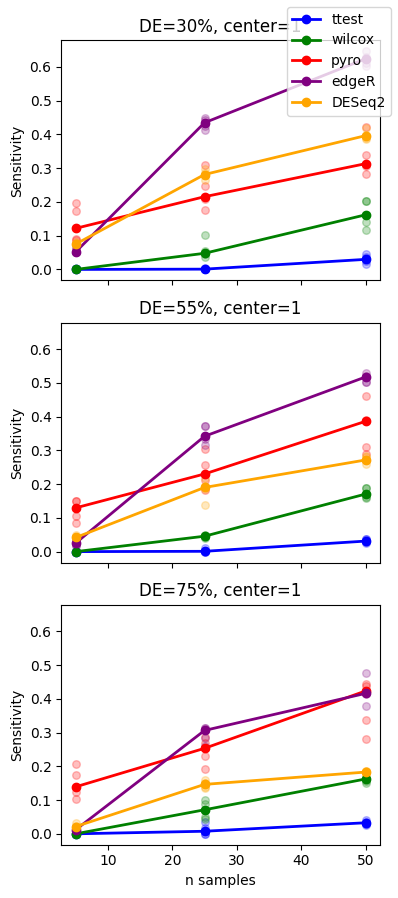

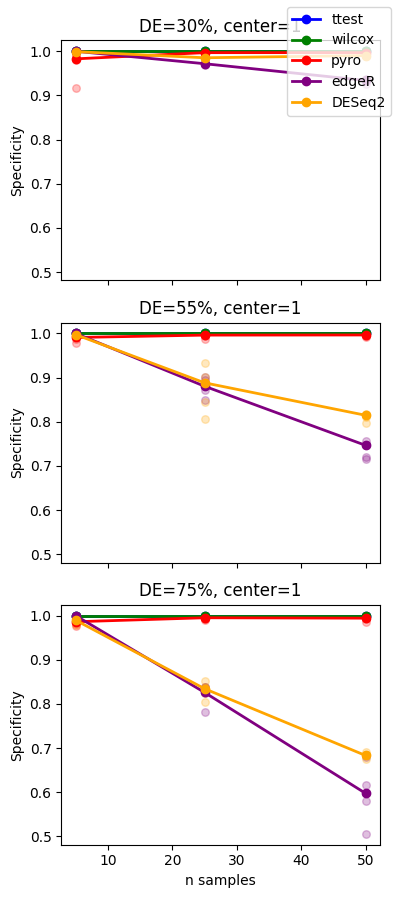

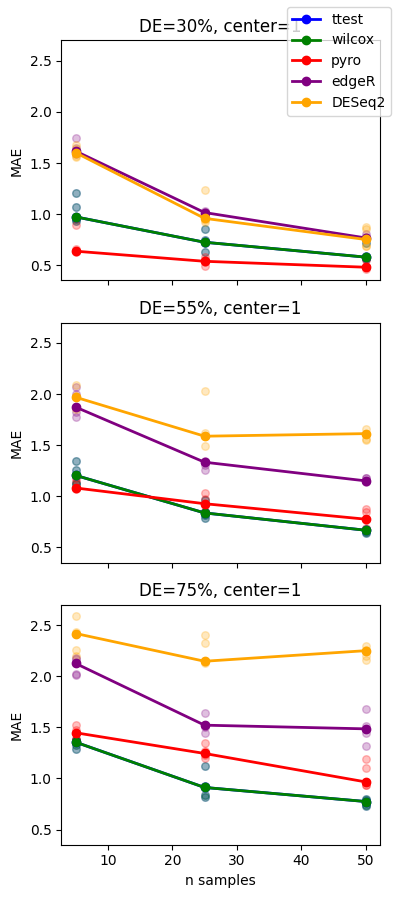

In [99]:
import matplotlib.pyplot as plt

def plot_metric(df, metric="sensitivity"):
    """Plot sensitivity, specificity, or MAE across sample sizes, faceted by DE% and center."""
    fig, axes = plt.subplots(
        nrows=len(df["de"].unique()),
        ncols=len(df["decenter"].unique()),
        figsize=(4 * df["decenter"].nunique(), 3 * df["de"].nunique()),
        sharex=True,
        sharey=True,
        squeeze=False
    )
    
    de_vals = sorted(df["de"].unique())
    decenter_vals = sorted(df["decenter"].unique())
    methods = ["ttest", "wilcox", "pyro", "edgeR", "DESeq2"]
    colors = {"ttest": "blue", "wilcox": "green", "pyro": "red", "edgeR": "purple", "DESeq2": "orange"}
    
    for i, de in enumerate(de_vals):
        for j, dc in enumerate(decenter_vals):
            ax = axes[i, j]
            subset = df[(df["de"] == de) & (df["decenter"] == dc)].copy()
            
            # Compute metric
            if metric == "sensitivity":
                denom = subset["TP"] + subset["FN"]
                subset["metric"] = np.where(denom > 0, subset["TP"] / denom, 0)
            elif metric == "specificity":
                denom = subset["TN"] + subset["FP"]
                subset["metric"] = np.where(denom > 0, subset["TN"] / denom, 0)
            else:  # MAE
                subset["metric"] = subset["MAE"]
            
            for method in methods:
                if method not in subset["method"].values:
                    continue
                m_data = subset[subset["method"] == method]
                
                # Scatter individual samples (light)
                ax.scatter(m_data["n"], m_data["metric"], 
                          color=colors[method], alpha=0.25, s=30)
                
                # Median line with markers
                median = m_data.groupby("n")["metric"].median().reset_index()
                ax.plot(median["n"], median["metric"], 
                       color=colors[method], marker="o", label=method, linewidth=2)
            
            ax.set_title(f"DE={de}%, center={dc}")
            if i == len(de_vals) - 1:
                ax.set_xlabel("n samples")
            if j == 0:
                ax.set_ylabel(metric.upper() if metric == "MAE" else metric.capitalize())
    
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

plot_metric(combined_df, "sensitivity")
plot_metric(combined_df, "specificity")
plot_metric(combined_df, "MAE")

In [108]:
#now we are going to compare witht the 
def run_pyro(counts, labels,cohort,gene_names, iterations=1000):
    pyro.clear_param_store()
    counts_t = torch.tensor(counts, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.float32)
    
    model = factor_model_nb_nosf()
    log_fc_init, log_mu0 = global_upreg_seq.prepare_initialization(counts_t, labels_t)
    guide = AutoNormal(model, init_loc_fn=init_to_value(values={"log_mu0": log_mu0, "log_fc": log_fc_init}), init_scale=0.1)
    optim = ClippedAdam({"lr": 0.3, "clip_norm": 100.0, "lrd": 0.0005**(1/iterations)})
    model, guide, _ = global_upreg_seq.train(counts_t, labels_t, model, num_iterations=iterations, optim=optim, guide=guide)

    #we take natural log of 2 because we want it to be 1 in the log2 base
    log10_bf, log_fc_est  = global_upreg_seq.calculate_foldchange_bf(guide, np.log(2.0), non_bf=True, make_plot=False)
    log2_fc_est = log_fc_est/np.log(2.0)
    pred_pos = log10_bf > 0.8

    return({"predicted_positive":pred_pos,
            "log2fc":log2_fc_est,
            "gene_name":gene_names})


# Load data
all_results = []
data_dir = "./data/"
files = list(Path(data_dir).glob("*_counts.csv"))
print(files)

for file in files:
    counts = pd.read_csv(file, index_col=0)
    project_name = file.stem.replace("_counts", "")
    metadata_path = data_dir + f"{project_name}metadata.csv"
    metadata = pd.read_csv(metadata_path, index_col=0)
    metadata['sample_type'] = metadata['tcga.tcga_barcode'].str[13:15]
    gene_names = counts.index
    # Filter for tumor (01) and normal (11) only
    valid = metadata['sample_type'].isin(['01', '11'])
    #if len(metadata[metadata['sample_type']=="11"]) <=1:
    #   print("not enough samples for ",project_name)
    #   continue  
    if project_name in ["HNSC", "COAD", "LIHC", "LUAD", "LUSC", "STAD", "THCA"]:    
        metadata, counts = metadata[valid], counts[metadata[valid].index]
        pyro_label= torch.tensor(metadata["sample_type"]=="01")
        all_results.append((project_name, run_pyro(torch.tensor(counts.values.T), pyro_label, project_name, gene_names, iterations =800)))
    else:
        continue




[PosixPath('data/OV_counts.csv'), PosixPath('data/THYM_counts.csv'), PosixPath('data/UCEC_counts.csv'), PosixPath('data/LUSC_counts.csv'), PosixPath('data/PCPG_counts.csv'), PosixPath('data/CESC_counts.csv'), PosixPath('data/BRCA_counts.csv'), PosixPath('data/KICH_counts.csv'), PosixPath('data/ESCA_counts.csv'), PosixPath('data/DLBC_counts.csv'), PosixPath('data/CHOL_counts.csv'), PosixPath('data/KIRP_counts.csv'), PosixPath('data/LIHC_counts.csv'), PosixPath('data/KIRC_counts.csv'), PosixPath('data/GBM_counts.csv'), PosixPath('data/LGG_counts.csv'), PosixPath('data/BLCA_counts.csv'), PosixPath('data/LAML_counts.csv'), PosixPath('data/STAD_counts.csv'), PosixPath('data/PRAD_counts.csv'), PosixPath('data/THCA_counts.csv'), PosixPath('data/COAD_counts.csv'), PosixPath('data/UCS_counts.csv'), PosixPath('data/SARC_counts.csv'), PosixPath('data/READ_counts.csv'), PosixPath('data/TGCT_counts.csv'), PosixPath('data/LUAD_counts.csv'), PosixPath('data/UVM_counts.csv'), PosixPath('data/PAAD_coun

<positron-console-cell-108>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
<positron-console-cell-108>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
<positron-console-cell-108>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
Loss: 1.015e+09: 100%|██████████| 800/800 [13:38<00:00,  1.02s/it]  
<positron-console-cell-108>:33: DtypeWarning: Columns (485,487,494,498,500,501) have mixed types. Specify dtype option on import or set low_memory=False.
<positron-console-cell-108>:43: FutureWarning: Series.__get

In [109]:
full_result_df = pd.DataFrame(all_results[0][1])
project_name = all_results[0][0]
full_result_df[full_result_df['predicted_positive']]
full_result_df[full_result_df['log2fc']>=0.0]
print(full_result_df['log2fc'].median())
full_result_df['log2fc'].mean()

0.005498471606638491


np.float64(0.2405800736264348)

0
1
2
3
4
5
6


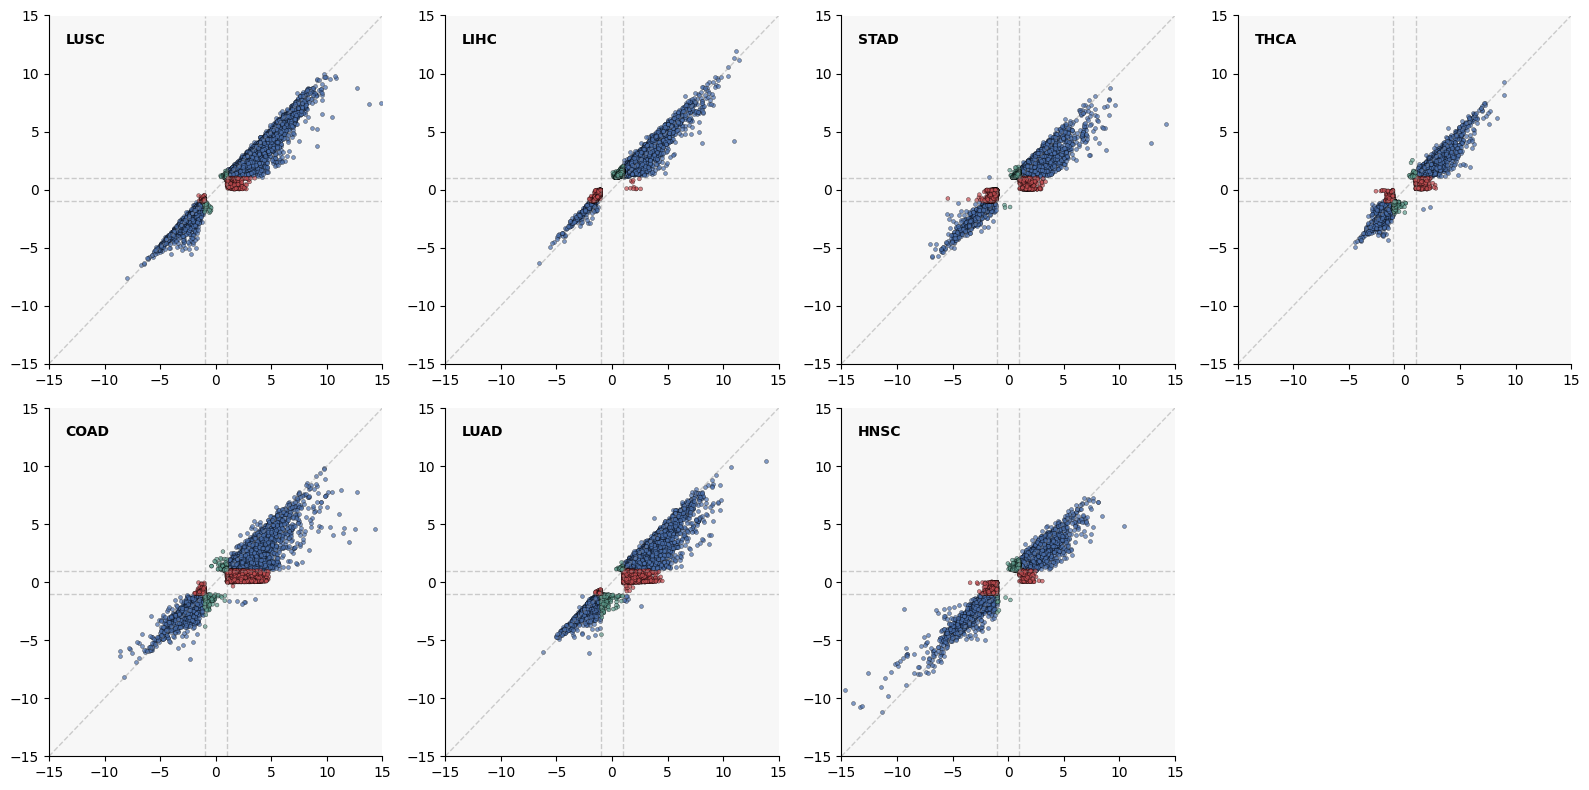

In [115]:
# Muted colors
muted_red = '#c44e52'
muted_blue = '#4c72b0'

n = len(all_results)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), facecolor='white')
axes = axes.flatten()

for i, (project_name, df) in enumerate(all_results):
    ax = axes[i]
    ax.set_facecolor('#f7f7f7')
    
    full_result_df = pd.DataFrame(df)
    tcga_difex = pd.read_csv("./tcga_exploration/tcga_differential_expression_all.csv")
    tcga_data = tcga_difex[tcga_difex['cancer_type']==project_name]
    tcga_data.columns = ['cancer_type', 'gene_name', 'deseqlog2fc', 'deseqp', 'deseqpadj']
    
    merged_df = full_result_df.merge(tcga_data, on='gene_name')
    merged_df = merged_df[
        ((~np.isnan(merged_df['deseqpadj'])) & (np.abs(merged_df['deseqlog2fc']) >=1.0) & (merged_df.deseqpadj <=0.05)) | 
        merged_df.predicted_positive
    ]
    
    colors = np.where((merged_df.log2fc > -1) & (merged_df.log2fc < 1), muted_red, muted_blue)
    deseq_hit =np.abs(merged_df.deseqlog2fc) >1
    allcolor = np.where(deseq_hit, colors, '#5f9e8f')

    #ax.scatter(merged_df.deseqlog2fc, merged_df.log2fc, c=allcolor, 
    #           s=8, edgecolors='black', linewidths=0.3, alpha=0.7)
    mask_blue = allcolor == muted_blue
    ax.scatter(merged_df.deseqlog2fc[mask_blue], merged_df.log2fc[mask_blue], 
           c=muted_blue, s=8, edgecolors='black', linewidths=0.3, alpha=0.7)
    ax.scatter(merged_df.deseqlog2fc[~mask_blue], merged_df.log2fc[~mask_blue], 
           c=allcolor[~mask_blue], s=8, edgecolors='black', linewidths=0.3, alpha=0.7)
    
    ax.set_ylim(-15, 15)
    ax.set_xlim(-15, 15)
    ax.axline((0, 0), slope=1, color='#888888', linestyle='--', alpha=0.4, lw=1)
    ax.axhline(y=1, color='#888888', linestyle='--', alpha=0.4, lw=1)
    ax.axhline(y=-1, color='#888888', linestyle='--', alpha=0.4, lw=1)
    ax.axvline(x=1, color='#888888', linestyle='--', alpha=0.4, lw=1)
    ax.axvline(x=-1, color='#888888', linestyle='--', alpha=0.4, lw=1)
    ax.text(0.05, 0.95, project_name, transform=ax.transAxes, 
            fontsize=10, fontweight='bold', va='top', ha='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('./tcga_exploration/newresults.svg', format='svg', bbox_inches='tight')
plt.show()

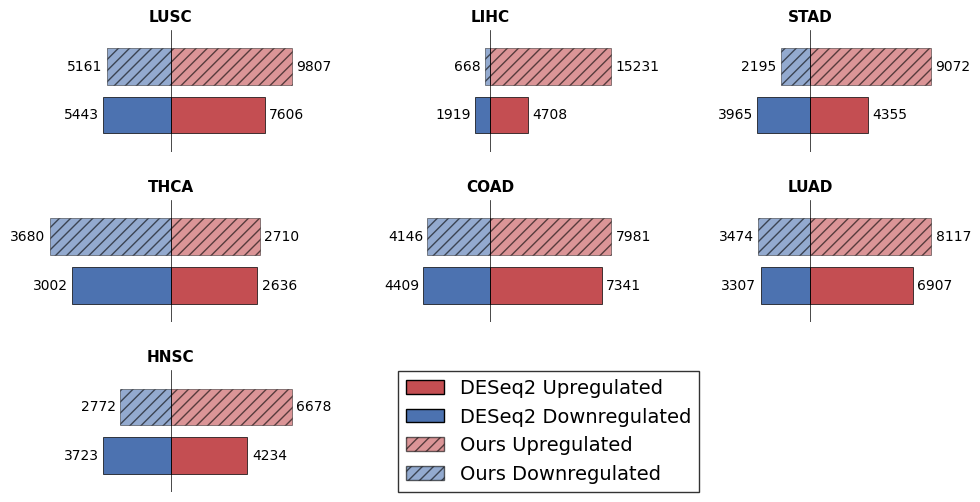

In [126]:
muted_red = '#c44e52'
muted_blue = '#4c72b0'
n = len(all_results)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2*rows), facecolor='white')
axes = axes.flatten()

for i, (project_name, df) in enumerate(all_results):
    ax = axes[i]
    
    full_result_df = pd.DataFrame(df)
    tcga_difex = pd.read_csv("./tcga_exploration/tcga_differential_expression_all.csv")
    tcga_data = tcga_difex[tcga_difex['cancer_type']==project_name]
    tcga_data.columns = ['cancer_type', 'gene_name', 'deseqlog2fc', 'deseqp', 'deseqpadj']
    
    merged_df = full_result_df.merge(tcga_data, on='gene_name')
    
    deseq_up = ((merged_df.deseqlog2fc > 1) & (merged_df.deseqpadj <= 0.05)).sum()
    deseq_down = ((merged_df.deseqlog2fc < -1) & (merged_df.deseqpadj <= 0.05)).sum()
    ours_up = (merged_df.log2fc > 1).sum()
    ours_down = (merged_df.log2fc < -1).sum()
    
    max_val = max(deseq_down, ours_down, deseq_up, ours_up) * 1.2
    
    # DESeq2 bars (solid)
    ax.barh([0], [-deseq_down], color=muted_blue, edgecolor='black', linewidth=0.5, height=0.3)
    ax.barh([0], [deseq_up], color=muted_red, edgecolor='black', linewidth=0.5, height=0.3)
    
    # Ours bars (hatched)
    ax.barh([0.4], [-ours_down], color=muted_blue, edgecolor='black', linewidth=0.5, height=0.3, hatch='///', alpha=0.6)
    ax.barh([0.4], [ours_up], color=muted_red, edgecolor='black', linewidth=0.5, height=0.3, hatch='///', alpha=0.6)
    
    ax.set_yticks([])
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-0.3, 0.7)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    
    ax.text(-deseq_down - max_val*0.03, 0, str(deseq_down), va='center', ha='right', fontsize=10)
    ax.text(-ours_down - max_val*0.03, 0.4, str(ours_down), va='center', ha='right', fontsize=10)
    ax.text(deseq_up + max_val*0.03, 0, str(deseq_up), va='center', ha='left', fontsize=10)
    ax.text(ours_up + max_val*0.03, 0.4, str(ours_up), va='center', ha='left', fontsize=10)
    
    ax.set_title(project_name, fontsize=11, fontweight='bold')

# Use last subplot for legend
ax_legend = axes[n]
ax_legend.axis('off')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=muted_red, edgecolor='black', label='DESeq2 Upregulated'),
    Patch(facecolor=muted_blue, edgecolor='black', label='DESeq2 Downregulated'),
    Patch(facecolor=muted_red, edgecolor='black', hatch='///', alpha=0.6, label='Ours Upregulated'),
    Patch(facecolor=muted_blue, edgecolor='black', hatch='///', alpha=0.6, label='Ours Downregulated'),
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, fontsize=14, 
                  edgecolor='black', fancybox=False, bbox_to_anchor=(0.7,0.5))

for j in range(n+1, len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(wspace=0.1, hspace=0.4)
plt.savefig('./tcga_exploration/barplots.svg', format='svg', bbox_inches='tight')
plt.show()